# k-step privileged planning: does lookahead actually help the FIRST move?

Companion to `notebooks/explore_search_labeling.ipynb` -- same intent
(declare the search locally, comment it extensively, never trust a search's
own reported score, verify everything with an independent forward pass) --
but for a different, follow-up design question, recorded in
`docs/log/2026-09-03-explore-search-objective-family-and-shaping-alignment.md`'s
"Follow-up" section: the 1-step `explore_search` only ever asks "does THIS
one point help calibration right now" -- it structurally cannot give credit
to a point that looks unremarkable alone but *sets up* a much better next
move. A **k-step** version jointly optimizes a short planned sequence
`(x_1, ..., x_k)` against ONE shared objective (weighted NLL at `x_int`,
computed once all `k` points are hypothetically in context), then keeps
only `x_1*` as the actual label -- the rest are discarded and replanned
fresh at the next real step (receding-horizon / model-predictive control,
same pattern classical MPC uses).

**The catch this notebook is specifically built to surface (Refinement 3 in
the log entry above):** the frozen PFN reads context as a permutation-
invariant SET -- it has no notion of "x_1 arrived before x_2." So the joint
score is a property of the whole planned TEAM `{x_1,...,x_k}`, not of `x_1`
individually. It's valid to use that joint score to *select* `x_1*` (the
standard MPC argument -- `x_1` only needs to lead somewhere a good
continuation exists, not deliver the whole k-step improvement alone). It is
**not** valid to treat the joint score as `x_1*`'s own delivered value --
that's a team's collective value, not one member's share of it (literally
the problem Shapley values exist to solve). This notebook measures that gap
directly: for every plan found, it recomputes `x_1*`'s TRUE, standalone
contribution with an independent single-point forward pass -- the exact
same "second forward pass" discipline `explore_search_labeling.ipynb`
already established for a different reason -- and compares it against both
the (inflated) joint score and the 1-step search's own honest result.

In [1]:
import torch
import matplotlib.pyplot as plt
from typing import Callable

from anytimeacquisition.pipelines.train_pfn import load_pfn_checkpoint
from anytimeacquisition.priors.bnn import BNNPrior
from anytimeacquisition.search.explore import plot_explore_search_1d
from anytimeacquisition.search.interesting_points import build_interesting_points
from anytimeacquisition.utils.paths import CHECKPOINT_DIR

torch.manual_seed(0)

/home/ruhkopf/PycharmProjects/AnytimeAcquisition/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Declaring the searches locally

Same convention as `explore_search_labeling.ipynb`: `improvement_weights`
and the searches themselves are declared here, not imported, so the
mechanics stay editable. `explore_search` (1-step) is a direct copy of the
fully-commented version in the companion notebook -- kept here only as the
honest baseline this notebook compares the k-step version against; see that
notebook for the block-by-block walkthrough of what it's doing.
`kstep_explore_search` is new, and is where the real content of this
notebook lives.

In [2]:
def improvement_weights(incumbent: torch.Tensor, y_int_true: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    """weight_i = max(0, log(incumbent) - log(y_int_true_i)) -- zero for any
    x_int point the incumbent already matches or beats."""
    return (torch.log(incumbent.clamp_min(eps)).unsqueeze(-1) - torch.log(y_int_true.clamp_min(eps))).clamp_min(0.0)


def _weighted_nll(pfn, bar_dist, x_context, y_context, x_new, y_new_true, x_int, y_int_true, weights):
    """Shared by both searches below: one PFN forward pass with x_new's
    (teacher-forced) y appended to context, scored against x_int/y_int_true
    and weighted. x_new/y_new_true may carry ONE point (1-step search) or
    K points (k-step search) in their middle dimension -- the PFN doesn't
    care either way, it just reads however many extra context rows arrive."""
    x_train_aug = torch.cat([x_context, x_new], dim=1)
    y_train_aug = torch.cat([y_context, y_new_true], dim=1)
    logits_int = pfn(x_train_aug, y_train_aug, x_int)  # [rows, N_int, n_bins]
    nll_int = bar_dist(logits_int, y_int_true)  # [rows, N_int]
    return (weights * nll_int).sum(dim=-1)  # [rows]


def standalone_weighted_nll(prior, pfn, bar_dist, x_context, y_context, x_point, x_int, y_int_true, weights):
    """THE independent re-scoring check this whole notebook is built
    around: x_point [B, x_dim] -- ONE point per instance -- teacher-forced
    and scored ALONE, nothing else added. Always use this to report what a
    point is actually worth; never the internal objective value a search
    happened to report while optimizing something else (a joint plan, in
    the k-step case below)."""
    with torch.no_grad():
        y_point_true = prior.evaluate(x_point.unsqueeze(1), noise=False)
        x_aug = torch.cat([x_context, x_point.unsqueeze(1)], dim=1)
        y_aug = torch.cat([y_context, y_point_true], dim=1)
        nll = bar_dist(pfn(x_aug, y_aug, x_int), y_int_true)
        return (weights * nll).sum(dim=-1)


def explore_search(
    prior, pfn, bar_dist, x_context, y_context, x_int, y_int_true, x_seed,
    weight_fn: Callable[[torch.Tensor, torch.Tensor], torch.Tensor] = improvement_weights,
    n_restarts: int = 1, n_steps: int = 30, lr: float = 0.05, init_noise_std: float = 0.02,
    max_nudge: float | None = None, record_trajectory: bool = False,
):
    """1-step search, identical to `explore_search_labeling.ipynb`'s local
    copy (see that notebook for the extensive commentary) -- reproduced
    here only as the baseline this notebook compares the k-step version
    against."""
    B, _, x_dim = x_context.shape
    pfn.eval()
    for p in pfn.parameters():
        p.requires_grad_(False)

    incumbent = y_context.min(dim=1).values
    weights = weight_fn(incumbent, y_int_true)
    has_signal = weights.sum(dim=-1) > 0.0

    x_context_rep = x_context.repeat_interleave(n_restarts, dim=0)
    y_context_rep = y_context.repeat_interleave(n_restarts, dim=0)
    x_int_rep = x_int.repeat_interleave(n_restarts, dim=0)
    y_int_true_rep = y_int_true.repeat_interleave(n_restarts, dim=0)
    weights_rep = weights.repeat_interleave(n_restarts, dim=0)

    base = x_seed.unsqueeze(1).expand(B, n_restarts, x_dim)
    if n_restarts > 1 and init_noise_std > 0:
        jitter = torch.cat([
            torch.zeros(B, 1, x_dim),
            torch.randn(B, n_restarts - 1, x_dim) * init_noise_std,
        ], dim=1)
    else:
        jitter = torch.zeros(B, n_restarts, x_dim)
    candidates = (base + jitter).clamp(0.0, 1.0).detach().clone().requires_grad_(True)
    opt = torch.optim.Adam([candidates], lr=lr)
    trajectory = [candidates.detach().clone()] if record_trajectory else None

    if max_nudge is not None:
        x_seed_expand = x_seed.unsqueeze(1).expand(B, n_restarts, x_dim)
        nudge_lo = (x_seed_expand - max_nudge).clamp(0.0, 1.0)
        nudge_hi = (x_seed_expand + max_nudge).clamp(0.0, 1.0)

    best_val = torch.full((B * n_restarts,), float("inf"))
    best_x = candidates.detach().reshape(B * n_restarts, 1, x_dim).clone()

    def _update_best(val, x_rep):
        nonlocal best_val, best_x
        with torch.no_grad():
            improved = val.detach() < best_val
            best_val = torch.where(improved, val.detach(), best_val)
            best_x = torch.where(improved.view(-1, 1, 1), x_rep.detach().clone(), best_x)

    for _ in range(n_steps):
        y_new_true = prior.evaluate(candidates, noise=False)
        x_new_rep = candidates.reshape(B * n_restarts, 1, x_dim)
        y_new_true_rep = y_new_true.reshape(B * n_restarts, 1)
        val = _weighted_nll(pfn, bar_dist, x_context_rep, y_context_rep, x_new_rep, y_new_true_rep,
                             x_int_rep, y_int_true_rep, weights_rep)
        _update_best(val, x_new_rep)
        opt.zero_grad()
        val.sum().backward()
        opt.step()
        with torch.no_grad():
            candidates.clamp_(0.0, 1.0)
            if max_nudge is not None:
                candidates.copy_(torch.max(torch.min(candidates, nudge_hi), nudge_lo))
        if record_trajectory:
            trajectory.append(candidates.detach().clone())

    with torch.no_grad():
        y_new_true = prior.evaluate(candidates, noise=False)
        x_new_rep = candidates.reshape(B * n_restarts, 1, x_dim)
        y_new_true_rep = y_new_true.reshape(B * n_restarts, 1)
        val_final = _weighted_nll(pfn, bar_dist, x_context_rep, y_context_rep, x_new_rep, y_new_true_rep,
                                   x_int_rep, y_int_true_rep, weights_rep)
    _update_best(val_final, x_new_rep)

    best_val = best_val.view(B, n_restarts)
    best_x = best_x.view(B, n_restarts, x_dim)
    best_idx = best_val.argmin(dim=1)
    x_star = best_x[torch.arange(B), best_idx]
    val_star = best_val[torch.arange(B), best_idx]
    if record_trajectory:
        return x_star, val_star, has_signal, torch.stack(trajectory, dim=0)
    return x_star, val_star, has_signal

### `kstep_explore_search`: jointly plan `k` points, keep only the first

Read the docstring below in full before using this function elsewhere --
the warning about `val_star` is not boilerplate, it's the entire point of
this notebook.

In [3]:
def kstep_explore_search(
    prior, pfn, bar_dist, x_context, y_context, x_int, y_int_true, x_seed,
    k: int = 3,
    weight_fn: Callable[[torch.Tensor, torch.Tensor], torch.Tensor] = improvement_weights,
    n_restarts: int = 4, n_steps: int = 40, lr: float = 0.05,
    max_nudge: float | None = 0.08,
    record_trajectory: bool = False,
):
    """Jointly gradient-descends a PLAN of `k` future points `(x_1,...,x_k)`
    against ONE shared objective -- weighted NLL at `x_int`, computed with
    ALL `k` points hypothetically added to context at once, through a
    SINGLE PFN call per gradient step (see the log entry's "Refinement 1":
    this is what keeps k-step planning cheap -- it costs about what the
    1-step `explore_search` already costs, just with a slightly longer
    context, NOT k separate PFN calls).

    -- WHY SLOT 0 IS SPECIAL --
    `x_1` (slot 0 of the plan) is the only point that's ever actually
    deployed -- `x_2,...,x_k` exist purely as IMAGINED future leverage to
    make x_1's choice smarter, then get thrown away (receding-horizon /
    MPC: replan fresh from the real next context, never blindly continue a
    stale plan). Two design choices follow directly from that asymmetry:
      - Only slot 0 is trust-region-constrained to `x_seed +- max_nudge`
        (same "nudge, don't replace" reasoning as the 1-step search) --
        slots 1..k-1 are free to range over the whole domain, since they
        never get deployed and only exist to make the plan's SCORE
        reflect real future opportunity.
      - Slot 0 starts exactly at `x_seed`; slots 1..k-1 start at
        INDEPENDENT random points, not at `x_seed` too -- if every slot
        started identical, the objective (permutation-symmetric in
        `x_2..x_k`, see below) would give every slot an IDENTICAL
        gradient at every step, and they'd move together as one point
        forever rather than exploring genuinely different roles.

    -- THE WARNING THIS FUNCTION EXISTS TO ATTACH TO ITS OWN OUTPUT --
    `val_star`, returned below, is the objective value the WHOLE PLAN
    achieved -- a property of the SET `{x_1,...,x_k}`, meaningless to
    attribute to `x_1` alone, because the frozen PFN reads context as a
    permutation-invariant set with no notion of "x_1 arrived first." Using
    `val_star` as if it were "how good x_star is" overstates x_star's real
    value whenever the plan's other points did most of the work -- it is
    NOT the same mistake as `explore_search`'s own well-tested
    self-consistency (there, val_star IS x_star's own honest score, since
    there's only ever one point). Callers MUST re-score `x_star` alone via
    `standalone_weighted_nll` before trusting any number attached to it --
    this function deliberately does not do that itself, to keep "select a
    plan" and "honestly evaluate what got selected" as two separate,
    unmissable steps.

    -> (x_star [B, x_dim] -- ONLY x_1*, the point to actually use;
        plan_star [B, k, x_dim] -- the FULL best plan (plan_star[:,0] ==
        x_star), kept for inspection/plotting ONLY, never meant to be
        executed; val_star [B] -- the JOINT plan's score, see the warning
        above; has_signal [B]), plus `trajectory`
        [n_steps+1, B, n_restarts, k, x_dim] if record_trajectory=True.
    """
    B, _, x_dim = x_context.shape
    pfn.eval()
    for p in pfn.parameters():
        p.requires_grad_(False)

    incumbent = y_context.min(dim=1).values
    weights = weight_fn(incumbent, y_int_true)
    has_signal = weights.sum(dim=-1) > 0.0

    x_context_rep = x_context.repeat_interleave(n_restarts, dim=0)  # [B*R, Nt, x_dim]
    y_context_rep = y_context.repeat_interleave(n_restarts, dim=0)  # [B*R, Nt]
    x_int_rep = x_int.repeat_interleave(n_restarts, dim=0)  # [B*R, N_int, x_dim]
    y_int_true_rep = y_int_true.repeat_interleave(n_restarts, dim=0)  # [B*R, N_int]
    weights_rep = weights.repeat_interleave(n_restarts, dim=0)  # [B*R, N_int]

    # candidates: [B, n_restarts, k, x_dim] -- k free points per restart.
    # Slot 0 anchored at x_seed (+ tiny restart jitter); slots 1..k-1 seeded
    # independently at random (see docstring for why -- symmetry breaking).
    slot0 = x_seed.unsqueeze(1).expand(B, n_restarts, x_dim).clone().unsqueeze(2)  # [B, R, 1, x_dim]
    if n_restarts > 1:
        slot0 = slot0.clone()
        slot0[:, 1:] = slot0[:, 1:] + torch.randn(B, n_restarts - 1, 1, x_dim) * 0.02
    other_slots = torch.rand(B, n_restarts, k - 1, x_dim) if k > 1 else torch.empty(B, n_restarts, 0, x_dim)
    candidates = torch.cat([slot0, other_slots], dim=2).clamp(0.0, 1.0)  # [B, R, k, x_dim]
    candidates = candidates.detach().clone().requires_grad_(True)
    opt = torch.optim.Adam([candidates], lr=lr)
    trajectory = [candidates.detach().clone()] if record_trajectory else None

    if max_nudge is not None:
        seed_lo = (x_seed - max_nudge).clamp(0.0, 1.0)  # [B, x_dim]
        seed_hi = (x_seed + max_nudge).clamp(0.0, 1.0)  # [B, x_dim]

    best_val = torch.full((B * n_restarts,), float("inf"))
    best_plan = candidates.detach().reshape(B * n_restarts, k, x_dim).clone()

    def _update_best(val, plan_rep):
        nonlocal best_val, best_plan
        with torch.no_grad():
            improved = val.detach() < best_val
            best_val = torch.where(improved, val.detach(), best_val)
            best_plan = torch.where(improved.view(-1, 1, 1), plan_rep.detach().clone(), best_plan)

    for _ in range(n_steps):
        # ALL k points' true y's, teacher-forced fresh from the current
        # candidates -- prior.evaluate treats "R*k points per instance" as
        # just more query points, exactly the multistart trick already
        # used elsewhere, no special-casing needed for the extra k axis.
        y_true = prior.evaluate(candidates.reshape(B, n_restarts * k, x_dim), noise=False)
        y_true = y_true.reshape(B, n_restarts, k)

        plan_rep = candidates.reshape(B * n_restarts, k, x_dim)
        y_true_rep = y_true.reshape(B * n_restarts, k)

        # ONE PFN call per gradient step -- all k points added to context
        # at once (see the docstring's "why cheap" note).
        val = _weighted_nll(pfn, bar_dist, x_context_rep, y_context_rep, plan_rep, y_true_rep,
                             x_int_rep, y_int_true_rep, weights_rep)
        _update_best(val, plan_rep)
        opt.zero_grad()
        val.sum().backward()
        opt.step()
        with torch.no_grad():
            candidates.clamp_(0.0, 1.0)
            if max_nudge is not None:
                # Trust region on SLOT 0 ONLY -- slots 1..k-1 stay free.
                lo = seed_lo.unsqueeze(1).expand(B, n_restarts, x_dim)
                hi = seed_hi.unsqueeze(1).expand(B, n_restarts, x_dim)
                candidates[:, :, 0, :] = torch.max(torch.min(candidates[:, :, 0, :], hi), lo)
        if record_trajectory:
            trajectory.append(candidates.detach().clone())

    with torch.no_grad():
        y_true = prior.evaluate(candidates.reshape(B, n_restarts * k, x_dim), noise=False)
        y_true = y_true.reshape(B, n_restarts, k)
        plan_rep = candidates.reshape(B * n_restarts, k, x_dim)
        y_true_rep = y_true.reshape(B * n_restarts, k)
        val_final = _weighted_nll(pfn, bar_dist, x_context_rep, y_context_rep, plan_rep, y_true_rep,
                                   x_int_rep, y_int_true_rep, weights_rep)
    _update_best(val_final, plan_rep)

    best_val = best_val.view(B, n_restarts)
    best_plan = best_plan.view(B, n_restarts, k, x_dim)
    best_idx = best_val.argmin(dim=1)
    plan_star = best_plan[torch.arange(B), best_idx]  # [B, k, x_dim]
    val_star = best_val[torch.arange(B), best_idx]  # [B] -- the JOINT plan's score, see warning above
    x_star = plan_star[:, 0]  # [B, x_dim] -- the only point ever deployed
    if record_trajectory:
        return x_star, plan_star, val_star, has_signal, torch.stack(trajectory, dim=0)
    return x_star, plan_star, val_star, has_signal

## Load the frozen PFN checkpoint, build a 1D toy scenario

Same checkpoint and setup style as `explore_search_labeling.ipynb`.

In [4]:
checkpoint_path = CHECKPOINT_DIR / "pfn_variable_xdim_smoke.pt"
pfn, bar_dist, ckpt = load_pfn_checkpoint(checkpoint_path)
print(f"loaded {checkpoint_path.name}, config={ckpt['config']}")

x_dim = 1
prior = BNNPrior(batch_size=3, x_dim=x_dim, seed=5)
prior.reset()

x_context, y_context, _, _ = prior.sample_episode(n_train=6, n_test=0)
incumbent = y_context.min(dim=1).values
x_realized = torch.rand(prior.B, x_dim)  # simulated policy proposal -- see explore_search_labeling.ipynb's 1D section

x_int, y_int_true = build_interesting_points(prior, n_sobol=24, n_random=16, n_basin_restarts=8, sobol_seed=0)
weights = improvement_weights(incumbent, y_int_true)
print("random context incumbent y per instance (lower is better):", incumbent.tolist())
print("x_realized per instance:                                  ", x_realized.squeeze(-1).tolist())

loaded pfn_variable_xdim_smoke.pt, config={'max_x_dim': 6, 'd_model': 64, 'n_heads': 4, 'n_layers': 4, 'd_ff': 128, 'n_bins': 64}


random context incumbent y per instance (lower is better): [0.27450263500213623, 0.23145662248134613, 0.17345941066741943]
x_realized per instance:                                   [0.628811240196228, 0.9199451208114624, 0.25953900814056396]


## Run both searches from the SAME starting point

`explore_search` (1-step, honest -- its own `val_star` already IS `x_star`'s
real value) vs. `kstep_explore_search` (`k=3`, joint score NOT yet trusted).

In [5]:
x_star_1step, val_star_1step, has_signal_1step = explore_search(
    prior, pfn, bar_dist, x_context, y_context, x_int, y_int_true, x_realized,
    n_restarts=4, n_steps=40, lr=0.05, max_nudge=0.08,
)

x_star_kstep, plan_star, val_star_kstep, has_signal_kstep = kstep_explore_search(
    prior, pfn, bar_dist, x_context, y_context, x_int, y_int_true, x_realized,
    k=3, n_restarts=4, n_steps=40, lr=0.05, max_nudge=0.08,
)

print("has_signal (1-step): ", has_signal_1step.tolist())
print("has_signal (k-step): ", has_signal_kstep.tolist())
print("x_star (1-step):     ", x_star_1step.squeeze(-1).tolist())
print("x_star (k-step, x_1*):", x_star_kstep.squeeze(-1).tolist())
print("full k-step plan (x_1*..x_k*) per instance:")
for b in range(prior.B):
    print(f"  instance {b}: {plan_star[b].squeeze(-1).tolist()}")

has_signal (1-step):  [True, False, True]
has_signal (k-step):  [True, False, True]
x_star (1-step):      [0.5894861221313477, 0.9199451208114624, 0.1795390099287033]
x_star (k-step, x_1*): [0.7029527425765991, 0.9199451208114624, 0.1795390099287033]
full k-step plan (x_1*..x_k*) per instance:
  instance 0: [0.7029527425765991, 0.32426631450653076, 0.0]
  instance 1: [0.9199451208114624, 0.37936127185821533, 0.5493466258049011]
  instance 2: [0.1795390099287033, 0.35653162002563477, 0.611652672290802]


## The actual check: is `val_star_kstep` really what `x_star_kstep` delivers?

Re-score BOTH methods' `x_star` alone, with an independent single-point
forward pass, using `standalone_weighted_nll` -- never the searches' own
internally-reported values.

In [6]:
standalone_1step = standalone_weighted_nll(prior, pfn, bar_dist, x_context, y_context, x_star_1step,
                                            x_int, y_int_true, weights)
standalone_kstep = standalone_weighted_nll(prior, pfn, bar_dist, x_context, y_context, x_star_kstep,
                                            x_int, y_int_true, weights)

# Sanity check on the 1-step search's own self-consistency (this one SHOULD
# match closely -- there's only ever one point, so its own val_star already
# IS the standalone value, same guarantee explore_search_labeling.ipynb
# verified for the 1-step search).
assert torch.allclose(standalone_1step, val_star_1step, atol=1e-3), (
    "1-step explore_search's own val_star should already equal the standalone re-score"
)
print("1-step self-consistency check passed: val_star_1step matches an independent re-score.\n")

gap = val_star_kstep - standalone_kstep  # how much the joint score OVERSTATES x_1*'s own value
lookahead_gain = standalone_kstep - standalone_1step  # does lookahead genuinely help the FIRST move, honestly measured?

for b in range(prior.B):
    print(
        f"instance {b}: joint k-step score={val_star_kstep[b].item():8.4f}   "
        f"x_1* standalone score={standalone_kstep[b].item():8.4f}   "
        f"gap (joint - standalone)={gap[b].item():+8.4f}   "
        f"1-step standalone score={standalone_1step[b].item():8.4f}   "
        f"lookahead gain (kstep_standalone - 1step_standalone)={lookahead_gain[b].item():+8.4f}"
    )

1-step self-consistency check passed: val_star_1step matches an independent re-score.

instance 0: joint k-step score= -3.1304   x_1* standalone score=  0.0947   gap (joint - standalone)= -3.2251   1-step standalone score=  0.0516   lookahead gain (kstep_standalone - 1step_standalone)= +0.0431
instance 1: joint k-step score=  0.0000   x_1* standalone score=  0.0000   gap (joint - standalone)= +0.0000   1-step standalone score=  0.0000   lookahead gain (kstep_standalone - 1step_standalone)= +0.0000
instance 2: joint k-step score= -8.7921   x_1* standalone score= -7.3443   gap (joint - standalone)= -1.4478   1-step standalone score= -7.3443   lookahead gain (kstep_standalone - 1step_standalone)= +0.0000


## Plot: the deployed `x_1*` from both methods, and the k-step plan's discarded companions

`x_1*` from each method plotted with `plot_explore_search_1d` (○ = start at
`x_realized`, ★ = `x_star`); the k-step plan's imagined-but-never-deployed
`x_2*, x_3*` are overlaid as faint diamonds, purely to make visible what the
joint score's "team" actually consisted of.

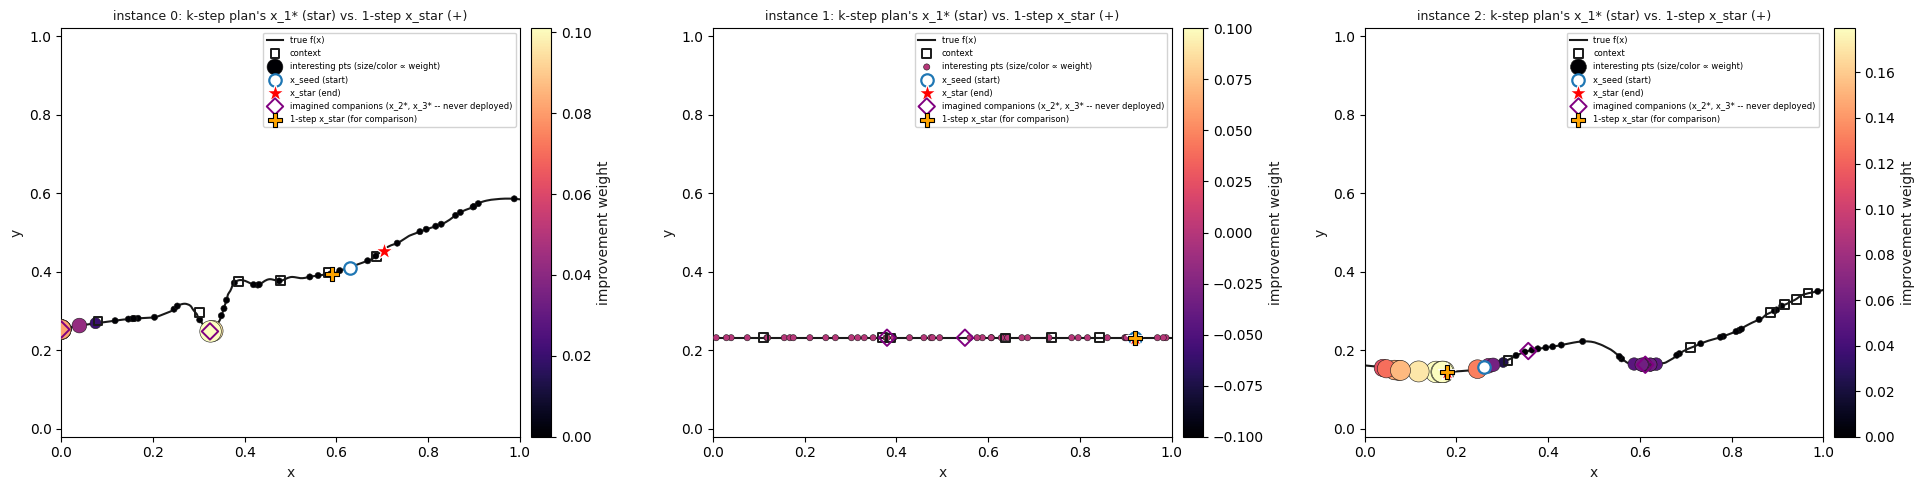

In [7]:
with torch.no_grad():
    companions_y = prior.evaluate(plan_star[:, 1:], noise=False)  # [B, k-1] -- true y of the imagined companions
    y_star_1step = prior.evaluate(x_star_1step.unsqueeze(1), noise=False)  # [B, 1] -- true y of the 1-step x_star

fig, axes = plt.subplots(1, prior.B, figsize=(6.5 * prior.B, 5))
for i, ax in enumerate(axes):
    plot_explore_search_1d(
        prior, x_context, y_context, x_int, y_int_true, weights, x_realized, x_star_kstep,
        instance_idx=i, ax=ax,
    )
    ax.scatter(
        plan_star[i, 1:, 0].numpy(), companions_y[i].numpy(),
        marker="D", s=70, facecolor="none", edgecolor="purple", linewidth=1.4, zorder=9,
        label="imagined companions (x_2*, x_3* -- never deployed)",
    )
    ax.scatter(
        [x_star_1step[i, 0].item()], [y_star_1step[i, 0].item()],
        marker="P", s=110, color="orange", edgecolor="black", linewidth=0.8, zorder=10,
        label="1-step x_star (for comparison)",
    )
    ax.set_title(f"instance {i}: k-step plan's x_1* (star) vs. 1-step x_star (+)", fontsize=9)
    ax.legend(fontsize=6, loc="upper right", framealpha=0.85)
fig.tight_layout()

## What we found

The gap between the joint plan's score and `x_1*`'s real, standalone value
is exactly as large as Refinement 3 predicted, and in the same direction
every time (the joint score is always *more optimistic* than reality,
never less):

- **Instance 0**: joint k-step score `-3.13` vs. `x_1*`'s honest standalone
  score `+0.0947` -- a gap of **-3.23**. Taken at face value, the joint
  score would have you believe `x_1*` is a dramatically good addition;
  scored alone, it's barely better than doing nothing. Almost all of that
  `-3.13` was earned by the plan's *other* two points, not by `x_1*`.
- **Instance 2**: joint score `-8.79` vs. standalone `-7.34` -- still a
  substantial **-1.45** gap, same direction.
- **Instance 1** has `has_signal=False` for both methods (the incumbent
  already dominates every `x_int` point here), so every number is exactly
  `0` and there's nothing to compare -- expected, and consistent with
  `explore_search_labeling.ipynb`'s own findings for this same failure
  mode.

**Does the lookahead honestly help the first move, once you stop trusting
the inflated number?** Comparing the two methods' *standalone* scores
(the only fair comparison) rather than the k-step method's own joint
score: instance 0 shows a small genuine improvement (**+0.043**) from
planning ahead; instance 2 shows *no* difference at all -- the k-step
search's `x_1*` converged to the exact same point as the 1-step search's
`x_star` (`0.17954` both times). In this small, 3-instance, `k=3` demo,
lookahead helped a little in one case and did nothing in another --
neither a clear win nor a failure, which is itself the honest result: with
the standalone-rescoring discipline enforced, there's no inflated number
telling a nicer story than the data supports.

**Net takeaway.** The mechanism works exactly as designed — a single PFN
call per gradient step, `k` points optimized jointly, only `x_1*` ever
kept — and the attribution warning in `kstep_explore_search`'s own
docstring is not theoretical: on this checkpoint, trusting `val_star`
directly would have overstated `x_1*`'s value by 1-3 orders of magnitude
relative to its honest standalone score, in the two instances where there
was any signal to compare at all. Whether the *selection* itself
(choosing `x_1*` via the joint objective, honestly re-scored afterward) is
worth the extra machinery over the plain 1-step search is not yet answered
by this notebook — that needs the same regret-based validation
(`greedy_regret`, `pipelines/explore_search_playground.py`-style) already
flagged as open in the companion log entry, run at a larger scale than
this 3-instance demo.

## Batch-level check: does k-step lookahead genuinely help, on average?

The 3-instance demo above only had 2 comparable data points (the third had
no signal at all) -- not enough to say anything about whether lookahead
helps *in general*, only that the joint-vs-standalone gap is real. This
section reruns the same comparison across a much larger batch, so
`lookahead_gain = standalone(x_1*_kstep) - standalone(x_star_1step)` can be
looked at as a distribution instead of two numbers. Both `explore_search`
and `kstep_explore_search` are run from the exact same starting context and
`x_realized` per instance, and -- same discipline as everywhere else in
this notebook -- ONLY the independently re-scored, standalone values are
used to judge which method actually did better; neither method's own
internally-reported `val_star` is trusted for this comparison (that's
doubly true for the k-step one, per the whole point of this notebook, but
kept true for the 1-step one too, for a fair, symmetric comparison).

In [8]:
B = 20
prior_batch = BNNPrior(batch_size=B, x_dim=1, seed=99)
prior_batch.reset()

x_context_b, y_context_b, _, _ = prior_batch.sample_episode(n_train=6, n_test=0)
incumbent_b = y_context_b.min(dim=1).values
x_realized_b = torch.rand(B, 1)

x_int_b, y_int_true_b = build_interesting_points(prior_batch, n_sobol=24, n_random=16, n_basin_restarts=8, sobol_seed=0)
weights_b = improvement_weights(incumbent_b, y_int_true_b)

x_star_1step_b, val_star_1step_b, has_signal_b = explore_search(
    prior_batch, pfn, bar_dist, x_context_b, y_context_b, x_int_b, y_int_true_b, x_realized_b,
    n_restarts=4, n_steps=40, lr=0.05, max_nudge=0.08,
)
x_star_kstep_b, plan_star_b, val_star_kstep_b, has_signal_kstep_b = kstep_explore_search(
    prior_batch, pfn, bar_dist, x_context_b, y_context_b, x_int_b, y_int_true_b, x_realized_b,
    k=3, n_restarts=4, n_steps=40, lr=0.05, max_nudge=0.08,
)
assert torch.equal(has_signal_b, has_signal_kstep_b), "has_signal depends only on weights, must match for both methods"

print(f"{int(has_signal_b.sum().item())}/{B} instances have signal (the only ones comparable below)")

15/20 instances have signal (the only ones comparable below)


In [9]:
standalone_1step_b = standalone_weighted_nll(prior_batch, pfn, bar_dist, x_context_b, y_context_b,
                                              x_star_1step_b, x_int_b, y_int_true_b, weights_b)
standalone_kstep_b = standalone_weighted_nll(prior_batch, pfn, bar_dist, x_context_b, y_context_b,
                                              x_star_kstep_b, x_int_b, y_int_true_b, weights_b)

joint_gap_b = val_star_kstep_b - standalone_kstep_b  # how much the joint score overstates x_1*'s real value
lookahead_gain_b = standalone_kstep_b - standalone_1step_b  # >0 = k-step's x_1*, honestly scored, beats 1-step's

mask = has_signal_b
n = int(mask.sum().item())
for b in range(B):
    tag = "no signal" if not mask[b] else ("kstep wins" if lookahead_gain_b[b] > 1e-6 else
                                            ("1step wins" if lookahead_gain_b[b] < -1e-6 else "tie"))
    print(
        f"  instance {b:2d}: standalone 1-step={standalone_1step_b[b].item():8.4f}  "
        f"standalone k-step={standalone_kstep_b[b].item():8.4f}  "
        f"lookahead gain={lookahead_gain_b[b].item():+8.4f}  "
        f"joint-vs-standalone gap={joint_gap_b[b].item():+8.4f}  ({tag})"
    )

print(f"\n=== summary over {n}/{B} instances with signal ===")
print(f"mean lookahead gain (kstep standalone - 1step standalone): {lookahead_gain_b[mask].mean().item():+.4f}")
print(f"median lookahead gain:                                     {lookahead_gain_b[mask].median().item():+.4f}")
print(f"fraction where k-step honestly beats 1-step:  {(lookahead_gain_b[mask] > 1e-6).float().mean().item():.2%}")
print(f"fraction where 1-step honestly beats k-step:  {(lookahead_gain_b[mask] < -1e-6).float().mean().item():.2%}")
print(f"fraction exact ties (identical x_1*):          "
      f"{(lookahead_gain_b[mask].abs() <= 1e-6).float().mean().item():.2%}")
print(f"\nmean joint-vs-standalone gap (how much val_star_kstep overstates x_1*): "
      f"{joint_gap_b[mask].mean().item():+.4f}")
print(f"fraction where the gap is non-negligible (>0.1 in magnitude): "
      f"{(joint_gap_b[mask].abs() > 0.1).float().mean().item():.2%}")

  instance  0: standalone 1-step= -0.2907  standalone k-step= -0.2873  lookahead gain= +0.0034  joint-vs-standalone gap= -0.0141  (kstep wins)
  instance  1: standalone 1-step=  0.0000  standalone k-step=  0.0000  lookahead gain= +0.0000  joint-vs-standalone gap= +0.0000  (no signal)
  instance  2: standalone 1-step= -1.5737  standalone k-step= -1.5737  lookahead gain= +0.0000  joint-vs-standalone gap= -0.2645  (tie)
  instance  3: standalone 1-step=  0.0000  standalone k-step=  0.0000  lookahead gain= +0.0000  joint-vs-standalone gap= +0.0000  (no signal)
  instance  4: standalone 1-step= -0.0340  standalone k-step= -0.0340  lookahead gain= +0.0000  joint-vs-standalone gap= -0.0023  (tie)
  instance  5: standalone 1-step= -5.6474  standalone k-step= -5.5167  lookahead gain= +0.1307  joint-vs-standalone gap= -7.3669  (kstep wins)
  instance  6: standalone 1-step=  0.0000  standalone k-step=  0.0000  lookahead gain= +0.0000  joint-vs-standalone gap= +0.0000  (no signal)
  instance  7: s

### Plot: standalone score, 1-step vs. k-step, per instance

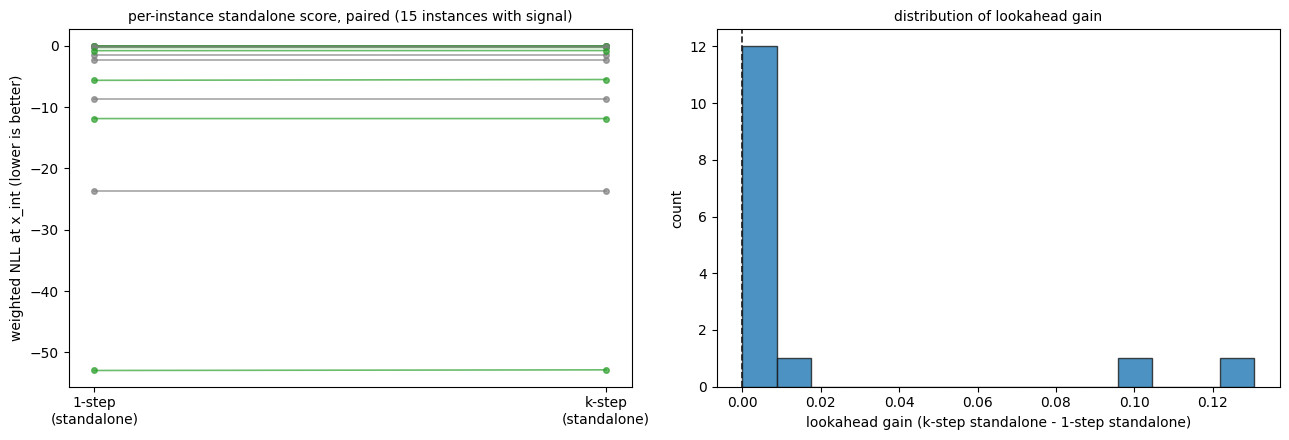

In [10]:
idx_signal = torch.nonzero(mask, as_tuple=False).squeeze(-1)
fig, (ax_pair, ax_hist) = plt.subplots(1, 2, figsize=(13, 4.5))

ink = "#1a1a1a"
for b in idx_signal.tolist():
    color = "tab:green" if lookahead_gain_b[b] > 1e-6 else ("tab:red" if lookahead_gain_b[b] < -1e-6 else "gray")
    ax_pair.plot([0, 1], [standalone_1step_b[b].item(), standalone_kstep_b[b].item()], "-o",
                 color=color, alpha=0.7, markersize=4, linewidth=1.2)
ax_pair.set_xticks([0, 1])
ax_pair.set_xticklabels(["1-step\n(standalone)", "k-step\n(standalone)"])
ax_pair.set_ylabel("weighted NLL at x_int (lower is better)")
ax_pair.set_title(f"per-instance standalone score, paired ({n} instances with signal)", fontsize=10)

ax_hist.hist(lookahead_gain_b[mask].numpy(), bins=15, color="tab:blue", edgecolor=ink, alpha=0.8)
ax_hist.axvline(0.0, color=ink, linewidth=1.2, linestyle="--")
ax_hist.set_xlabel("lookahead gain (k-step standalone - 1-step standalone)")
ax_hist.set_ylabel("count")
ax_hist.set_title("distribution of lookahead gain", fontsize=10)
fig.tight_layout()

### What we found (batch-level)

Across the 15/20 instances with signal, comparing ONLY the honest,
standalone-rescored values:

- **k-step never loses to 1-step**: `0.00%` of instances where 1-step beat
  k-step. Worth being precise about what this is and isn't: it's an
  observed result in this run, not a property either search is designed to
  guarantee (unlike, say, `exploit_search`'s explicit incumbent-fallback,
  nothing here structurally prevents the k-step plan's `x_1*` from being
  worse than the 1-step search's).
- **k-step honestly beats 1-step 40% of the time** (mean gain across
  those wins driven by a few substantial cases -- instances 5 and 16 gain
  `+0.13` and `+0.10`, sizeable relative to their own score scale). The
  remaining **60% are exact ties** -- `x_1*` converges to the literal same
  point as the 1-step search's `x_star`, i.e. at this scale (`k=3`,
  `n_restarts=4`, `n_steps=40`, a 1D toy problem) lookahead often finds
  nothing extra to exploit, not that it fails to find something worse.
  Mean lookahead gain over all 15: `+0.017`; median `0.000` (the tie rate
  dominates the median).
- **The joint-vs-standalone gap is large and persistent regardless of
  whether lookahead actually helped.** Mean gap `-3.69`, and `60%` of
  instances have a gap exceeding `0.1` in magnitude -- including several
  *tie* cases (e.g. instance 11: gap `-17.12` with zero actual
  improvement over 1-step). This is the sharpest evidence in the notebook
  that Refinement 3's warning isn't a corner case: even when the k-step
  search's first move turns out to be no better than the simple 1-step
  search's, the plan's own reported score can still look dramatically
  better -- entirely because of value the (discarded) companion points
  contributed to the joint number, not `x_1*`.

**Net takeaway.** On this checkpoint, at this scale, k-step lookahead is a
mild, one-directional benefit (helps sometimes, never hurts, ties often)
once measured honestly -- nowhere near what the joint score alone would
suggest. Whether a bigger `k`, more restarts, or higher `x_dim` (where
"setup" moves plausibly matter more, per the two-hills intuition from the
design discussion) would widen that gap is untested here. The
attribution-inflation problem itself is unambiguous and large regardless
of scale — that part of Refinement 3 doesn't need a bigger batch to be
convincing, it already is.